# Structured model — first 24 hours

This notebook trains the mortality model on the structured first-24h features.
It produces the out-of-fold cross-validated probabilities for the final feature
set (the baseline risk), turns them into tertile-based risk strata, and merges
the LLM-extracted features back in. It also contains the analysis of the
"unknown" (LLM-null) category in the structured data, including the statistical
tests on that group.

In [1]:
import os
import numpy as np 
import pandas as pd
import time  # To measure execution time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve

In [2]:
# Load base
df_base = pd.read_csv("../Outputs/ca_patients_filtered.csv")
df_base['hadm_id'] = df_base['hadm_id'].astype(int)

# List of files in desired merge order
merge_files = [
    ("vitals", "../Outputs/vitals_signs_preliminary.csv"),
    ("labs", "../Outputs/lab_vars_preliminary.csv"),
    ("comorbid", "../Outputs/comorbidities_finished.csv"),
    ("marking", "../Outputs/marking_system_finished.csv"),
    ("treatment", "../Outputs/treatment_info_finished.csv")
    #("has_notes", "../Preprocessing/has_radio_disch_notes.csv"),
    #("textual", "../Preprocessing/textual_data_preprocessed.csv"),
]

# Merge step-by-step, dropping duplicate columns (except hadm_id)
df_merged = df_base.copy()
base_columns = set(df_merged.columns)

for name, path in merge_files:
    df = pd.read_csv(path)
    df['hadm_id'] = df['hadm_id'].astype(int)

    # Drop any duplicate columns except 'hadm_id'
    duplicate_cols = base_columns.intersection(set(df.columns)) - {'hadm_id'}
    df = df.drop(columns=list(duplicate_cols))

    # Merge
    df_merged = df_merged.merge(df, on='hadm_id', how='left')
    base_columns.update(df.columns)

print(f"Final merged shape: {df_merged.shape}")

✅ Final merged shape: (2307, 51)


In [3]:
df_merged.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,myocardial_infarction,diabetes_mellitus,copd,GCS_Eye,GCS_Motor,GCS_Verbal,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,0,0,1,2.625,4.0,1.0,7.625,1,0,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,0,0,0,1.000,1.0,1.0,3.000,1,0,0
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,1,0,1,4.000,6.0,5.0,15.000,0,0,0
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,0,0,0,4.000,6.0,5.0,15.000,0,0,1
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,0,0,0,2.500,1.0,1.0,4.500,0,0,0


In [4]:
df_merged.to_csv("../Outputs/final_merged_dataset.csv", index=False)
print("Saved to ../Outputs/final_merged_dataset.csv")

Saved to ../Outputs/final_merged_dataset.csv


In [5]:
# List of columns to drop from df_merged
cols_to_drop = ['icd_code', 'intime', 'outtime', 'los', 'anchor_year', 'anchor_year_group', 'dischtime', 'deathtime', 'dod', 'GCS_Eye', 'GCS_Motor', 'GCS_Verbal']  # Replace with actual column names

# Drop unwanted columns
df = df_merged.drop(columns=cols_to_drop)

print(f"Final shape after dropping columns: {df.shape}")

✅ Final shape after dropping columns: (2307, 39)


In [6]:
# Get total rows
total_rows = df.shape[0]

# Calculate missing value percentage per column
missing_percent = df.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_percent[missing_percent > 0]

# Sort by highest missing %
missing_cols = missing_cols.sort_values(ascending=True)

# Display
print("Columns with missing values (% of rows):")
print(missing_cols)

📊 Columns with missing values (% of rows):
HR              0.260078
RR              0.606849
SBP             1.517122
SpO2            1.560468
DBP             1.647161
MBP             1.647161
GCS_Total       2.340702
Sodium          4.204595
Chloride        4.291287
Bicarbonate     4.377980
AnionGap        4.421326
Creatinine      4.421326
Potassium       4.508019
Hematocrit      4.594712
BUN             4.638058
Glucose         4.768097
Hemoglobin      4.854790
Platelet        5.071521
WBC             5.418292
Calcium         6.805375
INR            10.793238
PT             10.923277
BT             13.307326
pH             17.598613
Lactate        19.159081
dtype: float64


In [7]:
"""
# df should already be defined and cleaned as needed

# Step 1: Identify columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"Total columns with missing values: {len(missing_cols)}")

# Optional: drop textual or ID columns if they exist
exclude_cols = ['subject_id', 'hadm_id', 'stay_id', 'gender', 'anchor_age', 'survival_status']  # extend this list as needed
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
impute_targets = [col for col in missing_cols if col in numeric_cols and col not in exclude_cols]

# Step 2: Use other numeric features as predictors
impute_features = [col for col in numeric_cols if col not in exclude_cols]

# Step 3: Target variable (optional, if you're doing modeling too)
target = 'survival_status' if 'survival_status' in df.columns else None

# Step 4: Store Rubin’s rule results
rubin_results = {}

# Step 5: Run multiple imputations
for var in impute_targets:
    print(f"\nImputing variable: {var}")
    
    coefs, ses, imputed_versions = [], [], []

    for seed in range(5):
        imputer = IterativeImputer(random_state=seed, max_iter=10, sample_posterior=True)
        imputed_data = imputer.fit_transform(df[impute_features])
        imputed_df = pd.DataFrame(imputed_data, columns=impute_features)

        # Store imputed variable version
        imputed_versions.append(imputed_df[var].copy())

        if target:
            # Prepare data for modeling
            modeling_df = df.copy()
            modeling_df[var] = imputed_df[var]
            modeling_df = modeling_df.dropna(subset=[target] + impute_features)

            # Logistic regression for coefficient
            X = sm.add_constant(modeling_df[impute_features])
            y = modeling_df[target]

            try:
                model = sm.Logit(y, X).fit(disp=0)
                coefs.append(model.params[var])
                ses.append(model.bse[var])
            except Exception as e:
                print(f"Regression failed for seed {seed}: {e}")
                continue

    # Rubin’s Rule
    if coefs:
        m = len(coefs)
        beta_mi = np.mean(coefs)
        V = np.mean(np.square(ses))
        B = np.var(coefs, ddof=1)
        T = V + (1 + 1/m) * B
        se_mi = np.sqrt(T)

        rubin_results[var] = {
            'pooled_coef': beta_mi,
            'pooled_se': se_mi,
            '95%_CI': (beta_mi - 1.96 * se_mi, beta_mi + 1.96 * se_mi),
            'imputed_variable': pd.concat(imputed_versions, axis=1).mean(axis=1),
            'coefs': coefs,
            'ses': ses
        }

        print(f"Pooled β ({var}): {beta_mi:.4f}")
        print(f"± SE: {se_mi:.4f}")
        print(f"95% CI: [{beta_mi - 1.96 * se_mi:.4f}, {beta_mi + 1.96 * se_mi:.4f}]")
    else:
        print(f"Skipped Rubin’s rule for {var} due to missing regressions.")

# Step 6: Update final df with imputed values
for var in rubin_results:
    df[var] = rubin_results[var]['imputed_variable'].values

print("All imputed variables updated in the dataset.")
"""
print('remove imputation before out of fold cv!')

remove imputation before out of fold cv!


In [8]:
# Get total rows
total_rows = df.shape[0]

# Calculate missing value percentage per column
missing_percent = df.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_percent[missing_percent > 0]

# Sort by highest missing %
missing_cols = missing_cols.sort_values(ascending=True)

# Display
print("Columns with missing values (% of rows):")
print(missing_cols)

📊 Columns with missing values (% of rows):
HR              0.260078
RR              0.606849
SBP             1.517122
SpO2            1.560468
DBP             1.647161
MBP             1.647161
GCS_Total       2.340702
Sodium          4.204595
Chloride        4.291287
Bicarbonate     4.377980
AnionGap        4.421326
Creatinine      4.421326
Potassium       4.508019
Hematocrit      4.594712
BUN             4.638058
Glucose         4.768097
Hemoglobin      4.854790
Platelet        5.071521
WBC             5.418292
Calcium         6.805375
INR            10.793238
PT             10.923277
BT             13.307326
pH             17.598613
Lactate        19.159081
dtype: float64


In [9]:
df["gender"] = df["gender"].map({'F': 0, 'M': 1})

In [10]:
df.to_csv("../Outputs/final_structured_dataset.csv", index=False)
df_path = "../Outputs/final_structured_dataset.csv"
df = pd.read_csv(df_path)
df.head()

,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,0,68,1,71.392857,123.730769,75.320000,88.747692,...,7.340,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,0,45,1,106.461538,111.900000,73.545455,85.210606,...,7.190,1,0,0,0,0,3.000,1,0,0
2,10010471,29842315,32119961,0,89,1,86.920000,104.840000,54.280000,68.506667,...,NaN,1,1,1,0,1,15.000,0,0,0
3,10013569,27993048,38857852,0,54,0,80.285714,108.640000,59.080000,72.800000,...,7.350,1,1,0,0,0,15.000,0,0,1
4,10021454,29492087,33300154,1,88,1,57.920000,110.854130,48.005116,68.954787,...,7.362,1,0,0,0,0,4.500,0,0,0


## out of fold cv proabilities using final feature set

Fold 1 AUC: 0.7970
Fold 2 AUC: 0.7780
Fold 3 AUC: 0.7777
Fold 4 AUC: 0.7731
Fold 5 AUC: 0.7733

Overall OOF AUC: 0.7795
Mean fold AUC: 0.7798
Std fold AUC: 0.0088

Coefficient stability summary:
                          mean_coef  std_coef  min_coef  max_coef  range_coef  \
copd                       0.312612  0.083131  0.251830  0.454564    0.202734   
received_epinephrine      -0.688871  0.069221 -0.769295 -0.606008    0.163287   
Lactate                    0.404322  0.048665  0.359825  0.472536    0.112712   
SpO2                      -0.332637  0.048303 -0.385018 -0.264927    0.120091   
pH                        -0.018881  0.046102 -0.083699  0.029445    0.113144   
congestive_heart_failure  -0.337891  0.045339 -0.408534 -0.294138    0.114396   
AnionGap                   0.038456  0.037228 -0.018063  0.077489    0.095552   
const                      0.381060  0.034026  0.345004  0.431648    0.086644   
Bicarbonate               -0.089760  0.033996 -0.127975 -0.041321    0.08665

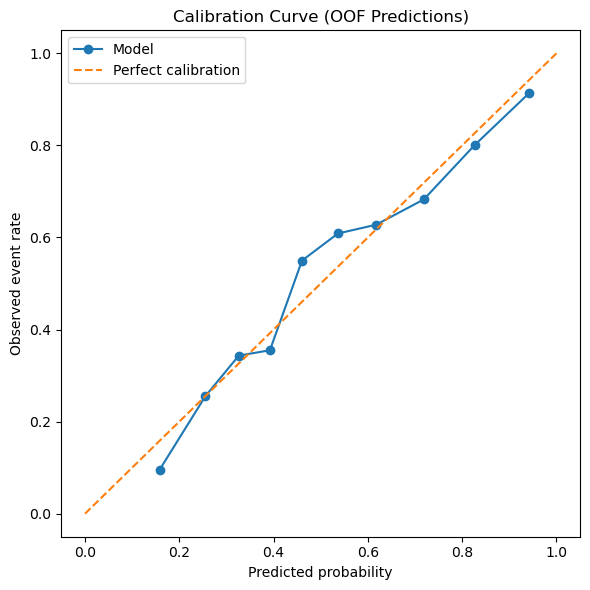


Calibration intercept: -0.0009
Calibration slope: 0.9574
Optimization terminated successfully.
         Current function value: 0.560217
         Iterations 6

Final model summary:
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 2307
Model:                          Logit   Df Residuals:                     2288
Method:                           MLE   Df Model:                           18
Date:                Fri, 03 Jul 2026   Pseudo R-squ.:                  0.1905
Time:                        11:24:13   Log-Likelihood:                -1292.4
converged:                       True   LL-Null:                       -1596.6
Covariance Type:            nonrobust   LLR p-value:                1.460e-117
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------


In [11]:
# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

final_vars = [
    'SBP', 'HR', 'Lactate', 'Hemoglobin', 'Bicarbonate', 'copd',
    'received_epinephrine', 'AnionGap', 'WBC', 'RR', 'BT', 'PT',
    'congestive_heart_failure', 'BUN', 'anchor_age', 'pH', 'SpO2', 'GCS_Total'
]

binary_vars = ['copd', 'received_epinephrine', 'congestive_heart_failure']
continuous_vars = [col for col in final_vars if col not in binary_vars]

# --------------------------------------------------
# PREPARE DATA
# --------------------------------------------------

df_model = df[['hadm_id', 'survival_status'] + final_vars].copy()

X_all = df_model[final_vars].copy()
y_all = df_model['survival_status'].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred_proba = np.full(len(df_model), np.nan)
fold_aucs = []
coef_list = []

# --------------------------------------------------
# 5-FOLD STRATIFIED OOF CV
# --------------------------------------------------

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_tr = X_all.iloc[train_idx].copy()
    X_val = X_all.iloc[val_idx].copy()
    y_tr = y_all.iloc[train_idx].copy()
    y_val = y_all.iloc[val_idx].copy()

    # ------------------------------
    # Imputation fit only on training fold
    # ------------------------------
    cont_imputer = SimpleImputer(strategy='median')
    bin_imputer = SimpleImputer(strategy='most_frequent')

    X_tr_cont = pd.DataFrame(
        cont_imputer.fit_transform(X_tr[continuous_vars]),
        columns=continuous_vars,
        index=X_tr.index
    )
    X_val_cont = pd.DataFrame(
        cont_imputer.transform(X_val[continuous_vars]),
        columns=continuous_vars,
        index=X_val.index
    )

    X_tr_bin = pd.DataFrame(
        bin_imputer.fit_transform(X_tr[binary_vars]),
        columns=binary_vars,
        index=X_tr.index
    )
    X_val_bin = pd.DataFrame(
        bin_imputer.transform(X_val[binary_vars]),
        columns=binary_vars,
        index=X_val.index
    )

    # Keep binary columns as integers
    X_tr_bin = X_tr_bin.round().astype(int)
    X_val_bin = X_val_bin.round().astype(int)

    # ------------------------------
    # Scaling fit only on training fold
    # ------------------------------
    scaler = StandardScaler()

    X_tr_cont_scaled = pd.DataFrame(
        scaler.fit_transform(X_tr_cont),
        columns=continuous_vars,
        index=X_tr.index
    )
    X_val_cont_scaled = pd.DataFrame(
        scaler.transform(X_val_cont),
        columns=continuous_vars,
        index=X_val.index
    )

    # ------------------------------
    # Recombine in original column order
    # ------------------------------
    X_tr_processed = pd.concat([X_tr_cont_scaled, X_tr_bin], axis=1)[final_vars]
    X_val_processed = pd.concat([X_val_cont_scaled, X_val_bin], axis=1)[final_vars]

    # Add intercept
    X_tr_processed = sm.add_constant(X_tr_processed, has_constant='add')
    X_val_processed = sm.add_constant(X_val_processed, has_constant='add')

    # ------------------------------
    # Fit model
    # ------------------------------
    model = sm.Logit(y_tr, X_tr_processed).fit(disp=0)

    # Store coefficients for stability analysis
    fold_params = model.params.copy()
    fold_params.name = f'fold_{fold}'
    coef_list.append(fold_params)

    # Predict on held-out fold
    oof_pred_proba[val_idx] = model.predict(X_val_processed)

    # Fold AUROC
    fold_auc = roc_auc_score(y_val, oof_pred_proba[val_idx])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold} AUC: {fold_auc:.4f}")

# --------------------------------------------------
# SAVE OOF PREDICTIONS
# --------------------------------------------------

df_model['baseline_risk_oof'] = oof_pred_proba

overall_oof_auc = roc_auc_score(y_all, df_model['baseline_risk_oof'])
print("\nOverall OOF AUC:", round(overall_oof_auc, 4))
print("Mean fold AUC:", round(np.mean(fold_aucs), 4))
print("Std fold AUC:", round(np.std(fold_aucs), 4))

df_model[['hadm_id', 'survival_status', 'baseline_risk_oof']].to_csv(
    "../Outputs/structured_baseline_risk_oof.csv",
    index=False
)

# --------------------------------------------------
# COEFFICIENT STABILITY ACROSS FOLDS
# --------------------------------------------------

coef_df = pd.DataFrame(coef_list)

# Sign consistency:
# True if coefficient sign is the same across all folds
def sign_consistent(series):
    signs = np.sign(series.dropna())
    unique_signs = pd.Series(signs).replace(0, np.nan).dropna().unique()
    return len(unique_signs) <= 1

coef_summary = pd.DataFrame({
    'mean_coef': coef_df.mean(),
    'std_coef': coef_df.std(),
    'min_coef': coef_df.min(),
    'max_coef': coef_df.max(),
    'range_coef': coef_df.max() - coef_df.min(),
    'sign_consistent': coef_df.apply(sign_consistent, axis=0)
})

# Optional: coefficient of variation where mean != 0
coef_summary['cv_abs'] = coef_summary['std_coef'] / coef_summary['mean_coef'].abs().replace(0, np.nan)

print("\nCoefficient stability summary:")
print(coef_summary.sort_values(by='std_coef', ascending=False))

#coef_summary.to_csv("../Outputs/structured_baseline_coef_stability.csv", index=True)

# Optional: raw fold coefficients
#coef_df.to_csv("../Outputs/structured_baseline_fold_coefficients.csv", index=True)

# --------------------------------------------------
# CALIBRATION ASSESSMENT
# --------------------------------------------------

# Brier score
brier = brier_score_loss(y_all, df_model['baseline_risk_oof'])
print("\nBrier score:", round(brier, 4))

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_all,
    df_model['baseline_risk_oof'],
    n_bins=10,
    strategy='quantile'
)

calibration_df = pd.DataFrame({
    'mean_predicted_probability': prob_pred,
    'observed_event_rate': prob_true
})
#calibration_df.to_csv("../Outputs/structured_baseline_calibration_curve.csv", index=False)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Observed event rate')
plt.title('Calibration Curve (OOF Predictions)')
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# CALIBRATION INTERCEPT AND SLOPE
# --------------------------------------------------

# To avoid infinite logits from 0 or 1 probabilities
eps = 1e-6
p_clipped = np.clip(df_model['baseline_risk_oof'], eps, 1 - eps)
logit_preds = np.log(p_clipped / (1 - p_clipped))

# Calibration intercept:
# outcome ~ 1 + offset(logit(pred))
calib_intercept_model = sm.GLM(
    y_all,
    np.ones((len(y_all), 1)),
    family=sm.families.Binomial(),
    offset=logit_preds
).fit()

calibration_intercept = calib_intercept_model.params.iloc[0]

# Calibration slope:
# outcome ~ 1 + logit(pred)
X_cal_slope = sm.add_constant(logit_preds)
calib_slope_model = sm.GLM(
    y_all,
    X_cal_slope,
    family=sm.families.Binomial()
).fit()

calibration_slope = calib_slope_model.params.iloc[1]

print("\nCalibration intercept:", round(calibration_intercept, 4))
print("Calibration slope:", round(calibration_slope, 4))

# Save calibration metrics
calibration_metrics = pd.DataFrame({
    'metric': [
        'overall_oof_auc',
        'mean_fold_auc',
        'std_fold_auc',
        'brier_score',
        'calibration_intercept',
        'calibration_slope'
    ],
    'value': [
        overall_oof_auc,
        np.mean(fold_aucs),
        np.std(fold_aucs),
        brier,
        calibration_intercept,
        calibration_slope
    ]
})

#calibration_metrics.to_csv("../Outputs/structured_baseline_validation_metrics.csv", index=False)

# --------------------------------------------------
# OPTIONAL FINAL MODEL ON FULL DATASET
# for interpretation / descriptive reporting
# --------------------------------------------------

cont_imputer = SimpleImputer(strategy='median')
bin_imputer = SimpleImputer(strategy='most_frequent')
scaler = StandardScaler()

X_cont_full = pd.DataFrame(
    cont_imputer.fit_transform(df_model[continuous_vars]),
    columns=continuous_vars,
    index=df_model.index
)

X_bin_full = pd.DataFrame(
    bin_imputer.fit_transform(df_model[binary_vars]),
    columns=binary_vars,
    index=df_model.index
).round().astype(int)

X_cont_full_scaled = pd.DataFrame(
    scaler.fit_transform(X_cont_full),
    columns=continuous_vars,
    index=df_model.index
)

X_full_processed = pd.concat([X_cont_full_scaled, X_bin_full], axis=1)[final_vars]
X_full_processed = sm.add_constant(X_full_processed, has_constant='add')

final_model = sm.Logit(df_model['survival_status'], X_full_processed).fit()
final_model.save("../Outputs/structured_baseline_final_model.pkl")

print("\nFinal model summary:")
print(final_model.summary())

# Save final model coefficients
final_coef_df = pd.DataFrame({
    'variable': final_model.params.index,
    'coef': final_model.params.values,
    'odds_ratio': np.exp(final_model.params.values),
    'p_value': final_model.pvalues.values,
    'ci_lower': final_model.conf_int()[0].values,
    'ci_upper': final_model.conf_int()[1].values,
    'or_ci_lower': np.exp(final_model.conf_int()[0].values),
    'or_ci_upper': np.exp(final_model.conf_int()[1].values),
})

#final_coef_df.to_csv("../Outputs/structured_baseline_final_model_coefficients.csv", index=False)

In [12]:
df_model_save = df_model.copy()

In [13]:
df_model = df_model_save.copy()

In [14]:
df_model

,hadm_id,survival_status,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,received_epinephrine,AnionGap,...,RR,BT,PT,congestive_heart_failure,BUN,anchor_age,pH,SpO2,GCS_Total,baseline_risk_oof
0,26184834,1,123.730769,71.392857,1.300000,10.90,33.000000,1,0,11.000000,...,17.357143,97.832632,14.400000,0,28.000000,68,7.340000,98.259259,7.625000,0.361723
1,22096005,1,111.900000,106.461538,3.400000,19.10,13.000000,0,0,14.000000,...,25.333333,97.533333,11.700000,0,23.000000,45,7.190000,96.357143,3.000000,0.496521
2,29842315,1,104.840000,86.920000,2.150000,11.30,26.000000,1,0,23.000000,...,15.880000,97.880000,12.200000,1,55.000000,89,NaN,97.480000,15.000000,0.387654
3,27993048,0,108.640000,80.285714,NaN,11.35,30.000000,0,0,19.000000,...,17.333333,97.888947,12.600000,1,79.000000,54,7.350000,96.037037,15.000000,0.262898
4,29492087,1,110.854130,57.920000,2.950000,12.35,19.500000,0,0,12.750000,...,20.120000,96.387200,18.950000,0,16.750000,88,7.362000,99.920000,4.500000,0.576511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2302,25848942,0,130.208333,86.680000,1.150000,12.60,24.000000,1,0,15.000000,...,20.520000,98.642857,NaN,0,49.000000,69,7.250000,96.640000,12.375000,0.428272
2303,21588174,1,108.769231,70.261538,0.800000,6.10,24.500000,1,0,17.500000,...,18.606061,97.373333,25.100000,1,82.000000,64,7.400000,98.609375,14.857143,0.514378
2304,29695607,0,93.315440,122.041667,3.757143,9.72,18.800000,0,1,16.000000,...,25.148936,99.530000,13.840000,0,42.200000,67,7.279091,90.317073,3.166667,0.782369
2305,23077223,0,87.500000,86.652174,NaN,10.60,20.000000,0,0,16.000000,...,17.434783,98.150000,15.066667,1,14.333333,81,7.450000,95.826087,14.500000,0.341488


#### OOF AUC: 0.7756051818935 --> randomly pick one patient who died and one who survived, the model assigns a higher death risk to the patient who died about 77.6% of the time.

## tertiles based strata labels

In [56]:
# Compute cutoffs
q1 = df_model['baseline_risk_oof'].quantile(1/3)
q2 = df_model['baseline_risk_oof'].quantile(2/3)

print("Low risk:    <=", q1)
print("Medium risk: >", q1, "and <=", q2)
print("High risk:   >", q2)

# Apply manually
df_model['risk_strata_3'] = pd.cut(
    df_model['baseline_risk_oof'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

print(df_model['risk_strata_3'].value_counts())

Low risk:    <= 0.3792691290789359
Medium risk: > 0.3792691290789359 and <= 0.6311930074883765
High risk:   > 0.6311930074883765
risk_strata_3
low       769
medium    769
high      769
Name: count, dtype: int64


# merge extracted features into dataframes

In [57]:
lactate_path_result = "../LLM Feature Extraction/outputs/lactate_extraction_results_2026-04-02_14-10-58.csv"
shock_path_result = "../LLM Feature Extraction/outputs/shock_extraction_results_2026-04-10_21-57-35.csv" #"../LLM Feature Extraction/outputs/shock_extraction_results_2026-04-02_16-36-31.csv"
coma_path_result = "../LLM Feature Extraction/outputs/coma_extraction_results_2026-05-13_22-55-31.csv" #"../LLM Feature Extraction/outputs/coma_extraction_results_2026-04-04_12-38-53.csv"

lactate_df = pd.read_csv(lactate_path_result)
shock_df = pd.read_csv(shock_path_result)
coma_df = pd.read_csv(coma_path_result)

In [58]:
df_model = (df_model.merge(lactate_df[['hadm_id', 'llm_present']], on='hadm_id', how='inner')
    .rename(columns={'llm_present':'llm_present_lactate'}))

df_model = (df_model.merge(shock_df[['hadm_id', 'llm_present', 'llm_severity']], on='hadm_id', how='inner')
    .rename(columns={'llm_present':'llm_present_shock', 'llm_severity':'llm_severity_shock'}))

df_model = (df_model.merge(coma_df[['hadm_id', 'llm_present']], on='hadm_id', how='inner')
    .rename(columns={'llm_present':'llm_present_coma'}))

In [59]:
df_model

,hadm_id,survival_status,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,received_epinephrine,AnionGap,...,anchor_age,pH,SpO2,GCS_Total,baseline_risk_oof,risk_strata_3,llm_present_lactate,llm_present_shock,llm_severity_shock,llm_present_coma
0,26184834,1,123.730769,71.392857,1.300000,10.900000,33.000000,1,0,11.000000,...,68,7.340000,98.259259,7.625000,0.361723,low,True,NaN,NaN,NaN
1,29842315,1,104.840000,86.920000,2.150000,11.300000,26.000000,1,0,23.000000,...,89,NaN,97.480000,15.000000,0.387654,medium,True,True,severe,False
2,27993048,0,108.640000,80.285714,NaN,11.350000,30.000000,0,0,19.000000,...,54,7.350000,96.037037,15.000000,0.262898,low,NaN,False,none,True
3,25154057,1,130.120000,63.111111,4.600000,8.300000,20.000000,1,0,20.333333,...,78,7.350000,99.888889,7.566667,0.724034,high,True,True,moderate,True
4,24614671,1,100.848039,72.111111,5.508333,10.983333,16.142857,0,0,20.571429,...,78,7.234286,88.205882,6.666667,0.851821,high,True,True,severe,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1613,20917922,0,101.000000,86.812500,1.100000,9.100000,25.750000,0,0,11.250000,...,46,7.360000,96.312500,9.500000,0.314087,low,True,True,severe,False
1614,25848942,0,130.208333,86.680000,1.150000,12.600000,24.000000,1,0,15.000000,...,69,7.250000,96.640000,12.375000,0.428272,medium,False,True,moderate,False
1615,21588174,1,108.769231,70.261538,0.800000,6.100000,24.500000,1,0,17.500000,...,64,7.400000,98.609375,14.857143,0.514378,medium,NaN,True,severe,False
1616,29695607,0,93.315440,122.041667,3.757143,9.720000,18.800000,0,1,16.000000,...,67,7.279091,90.317073,3.166667,0.782369,high,True,True,severe,True


In [60]:
df_model.to_csv("../Outputs/model_df_final.csv")

In [18]:
def summarize_binary_feature(df, feature_col, risk_col='baseline_risk_oof'):
    tmp = df[[feature_col, risk_col]].copy()
    tmp = tmp.dropna(subset=[risk_col])
    
    # Keep null feature values visible as separate category
    tmp[feature_col] = tmp[feature_col].astype('object').where(tmp[feature_col].notna(), 'unknown')
    
    summary = (
        tmp.groupby(feature_col)[risk_col]
        .agg(
            n='count',
            mean='mean',
            median='median',
            std='std',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            min='min',
            max='max'
        )
        .round(4)
    )
    
    display(summary)
    
    # Plot
    groups = []
    labels = []
    for label, g in tmp.groupby(feature_col):
        groups.append(g[risk_col].values)
        labels.append(str(label))
    
    plt.figure(figsize=(6, 4))
    plt.boxplot(groups, tick_labels=labels)
    plt.ylabel(risk_col)
    plt.title(f'{risk_col} by {feature_col}')
    plt.show()
    
    # Statistical test only for true vs false if both exist
    vals_true = tmp.loc[tmp[feature_col] == True, risk_col]
    vals_false = tmp.loc[tmp[feature_col] == False, risk_col]
    
    if len(vals_true) > 0 and len(vals_false) > 0:
        stat, p = mannwhitneyu(vals_true, vals_false, alternative='two-sided')
        print(f"Mann–Whitney U test for {feature_col}: U={stat:.3f}, p={p:.6f}")
        print(f"Median True:  {vals_true.median():.4f}")
        print(f"Median False: {vals_false.median():.4f}")
    else:
        print(f"Not enough True/False data for Mann–Whitney test in {feature_col}")


def summarize_ordinal_feature(df, feature_col, order, risk_col='baseline_risk_oof'):
    tmp = df[[feature_col, risk_col]].copy()
    tmp = tmp.dropna(subset=[risk_col, feature_col]).copy()
    
    tmp[feature_col] = pd.Categorical(tmp[feature_col], categories=order, ordered=True)
    tmp = tmp.sort_values(feature_col)
    
    summary = (
        tmp.groupby(feature_col, observed=True)[risk_col]
        .agg(
            n='count',
            mean='mean',
            median='median',
            std='std',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75)
        )
        .round(4)
    )
    
    display(summary)
    
    # Boxplot
    groups = [tmp.loc[tmp[feature_col] == level, risk_col].values for level in order if level in tmp[feature_col].values]
    labels = [level for level in order if level in tmp[feature_col].values]
    
    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, tick_labels=labels)
    plt.ylabel(risk_col)
    plt.title(f'{risk_col} by {feature_col}')
    plt.show()
    
    # Kruskal-Wallis across severity groups
    valid_groups = [g for g in groups if len(g) > 0]
    if len(valid_groups) >= 2:
        stat, p = kruskal(*valid_groups)
        print(f"Kruskal-Wallis test for {feature_col}: H={stat:.3f}, p={p:.6f}")
    
    # Optional monotonic trend check
    tmp_numeric = tmp.copy()
    tmp_numeric['severity_num'] = tmp_numeric[feature_col].cat.codes
    corr, p_corr = spearmanr(tmp_numeric['severity_num'], tmp_numeric[risk_col])
    print(f"Spearman trend for {feature_col}: rho={corr:.4f}, p={p_corr:.6f}")

,n,mean,median,std,q25,q75,min,max
llm_present_lactate,,,,,,,,
False,230,0.4483,0.4261,0.2121,0.2851,0.5738,0.0823,0.9771
True,790,0.5783,0.5735,0.2379,0.3852,0.7756,0.0763,0.9963
unknown,598,0.4456,0.4146,0.2170,0.2757,0.5984,0.0630,0.9825


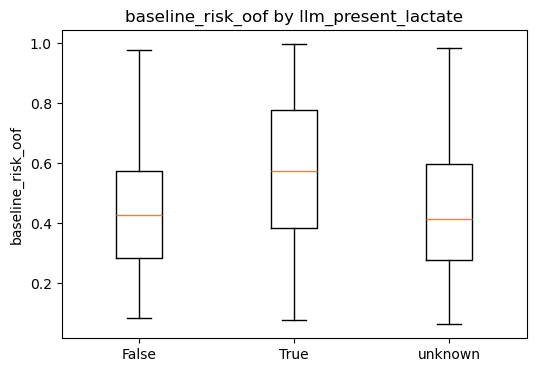

Mann–Whitney U test for llm_present_lactate: U=119522.000, p=0.000000
Median True:  0.5735
Median False: 0.4261


,n,mean,median,std,q25,q75,min,max
llm_present_shock,,,,,,,,
False,222,0.4087,0.3705,0.1936,0.2572,0.5218,0.1045,0.9605
True,1226,0.5380,0.5233,0.2384,0.3482,0.7293,0.0630,0.9963
unknown,170,0.4479,0.4083,0.2221,0.2932,0.5936,0.0747,0.9825


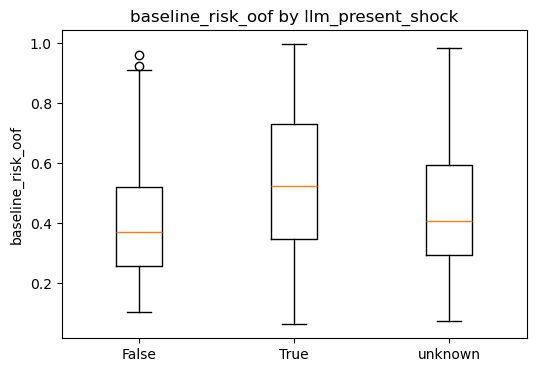

Mann–Whitney U test for llm_present_shock: U=179608.000, p=0.000000
Median True:  0.5233
Median False: 0.3705


,n,mean,median,std,q25,q75,min,max
llm_present_coma,,,,,,,,
False,756,0.4332,0.3929,0.2149,0.2635,0.5832,0.0630,0.9825
True,615,0.5687,0.5596,0.2353,0.3764,0.7552,0.0763,0.9953
unknown,247,0.6040,0.5786,0.2256,0.4339,0.8164,0.1488,0.9963


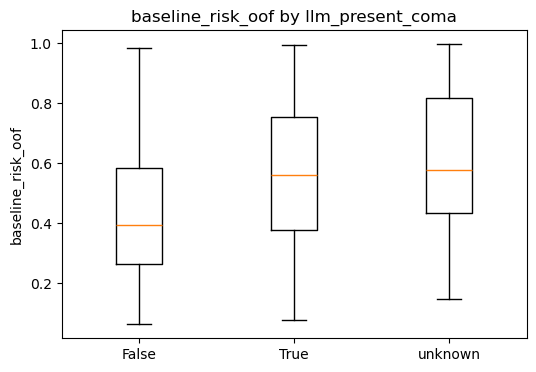

Mann–Whitney U test for llm_present_coma: U=309561.000, p=0.000000
Median True:  0.5596
Median False: 0.3929


,n,mean,median,std,q25,q75
llm_severity_shock,,,,,,
none,222,0.4087,0.3705,0.1936,0.2572,0.5218
mild,239,0.4121,0.3813,0.2045,0.2519,0.5529
moderate,159,0.5457,0.5536,0.2092,0.3620,0.7091
severe,815,0.5743,0.5655,0.2397,0.3865,0.7806


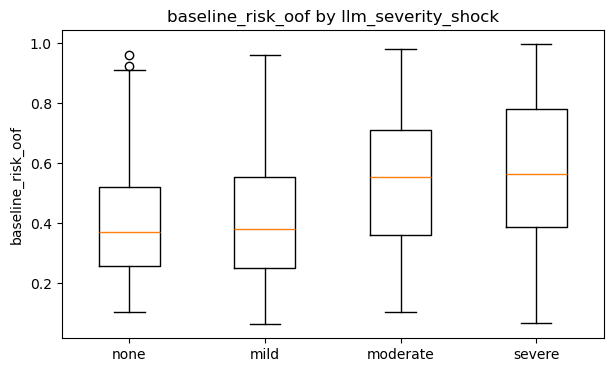

Kruskal-Wallis test for llm_severity_shock: H=144.944, p=0.000000
Spearman trend for llm_severity_shock: rho=0.2981, p=0.000000


In [19]:
summarize_binary_feature(df_model, 'llm_present_lactate')
summarize_binary_feature(df_model, 'llm_present_shock')
summarize_binary_feature(df_model, 'llm_present_coma')

summarize_ordinal_feature(
    df_model,
    'llm_severity_shock',
    order=['none', 'mild', 'moderate', 'severe']
)

## Correlation Between Variables

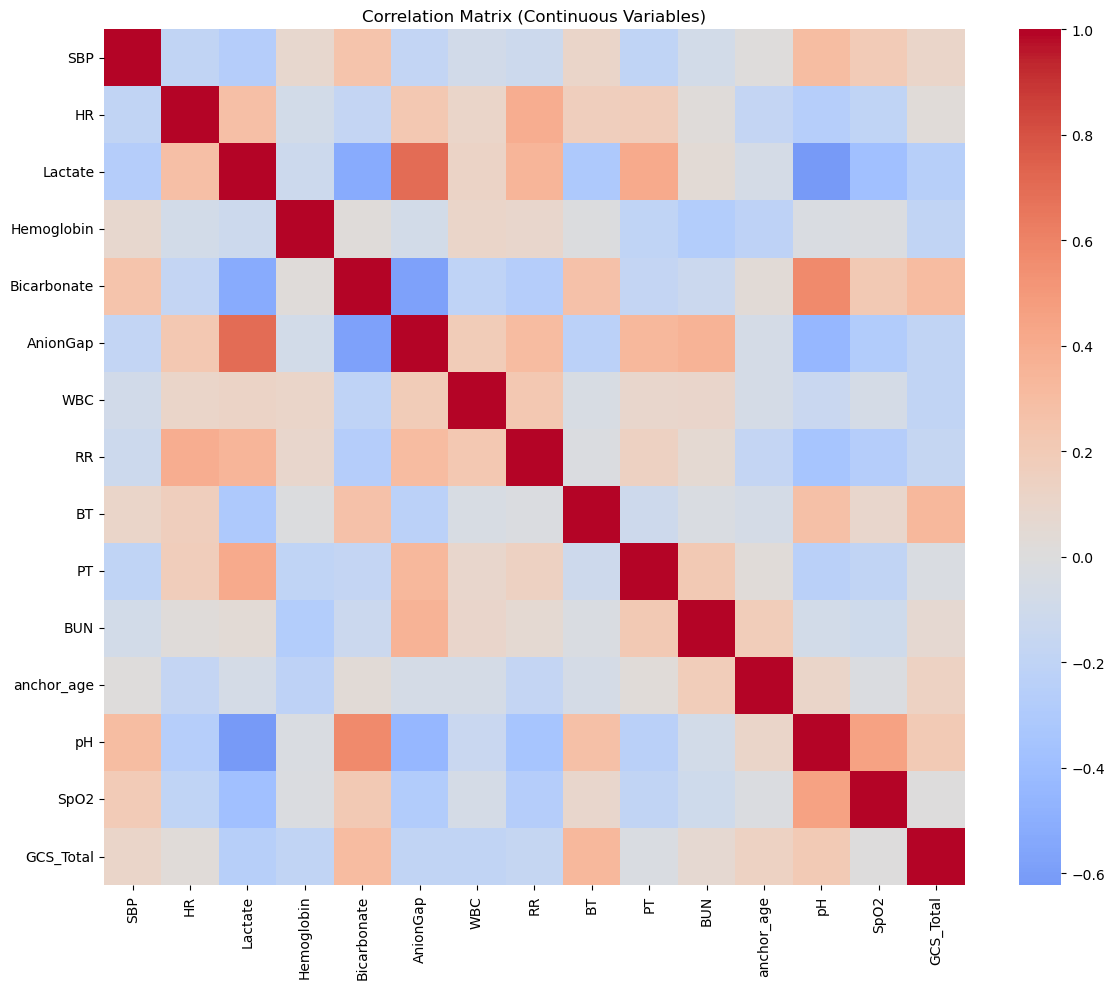


Top correlated feature pairs:
Lactate      AnionGap       0.697125
AnionGap     Lactate        0.697125
pH           Lactate        0.622626
Lactate      pH             0.622626
AnionGap     Bicarbonate    0.584439
Bicarbonate  AnionGap       0.584439
pH           Bicarbonate    0.573900
Bicarbonate  pH             0.573900
Lactate      Bicarbonate    0.526938
Bicarbonate  Lactate        0.526938
SpO2         pH             0.457818
pH           SpO2           0.457818
AnionGap     pH             0.448951
pH           AnionGap       0.448951
PT           Lactate        0.406822
dtype: float64


In [20]:
# Only continuous variables (correlation makes most sense here)
corr = df_model[continuous_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix (Continuous Variables)")
plt.tight_layout()
plt.show()

# Optional: print top correlated pairs
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

# remove self correlations
corr_pairs = corr_pairs[corr_pairs < 1]

print("\nTop correlated feature pairs:")
print(corr_pairs.head(15))

In [21]:
# Keep only upper triangle (no duplicates)
corr_matrix = df_model[final_vars].corr(method='spearman').abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_corr = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
)

print("\nTop correlated feature pairs:")
print(top_corr.head(15))


Top correlated feature pairs:
pH                    Bicarbonate             0.569805
AnionGap              Bicarbonate             0.550977
                      Lactate                 0.527210
pH                    Lactate                 0.519226
Bicarbonate           Lactate                 0.468008
BUN                   AnionGap                0.443992
received_epinephrine  Lactate                 0.423166
PT                    Lactate                 0.406017
RR                    HR                      0.377111
                      Lactate                 0.369968
pH                    AnionGap                0.360863
                      RR                      0.345220
GCS_Total             Bicarbonate             0.331464
SpO2                  pH                      0.323695
GCS_Total             received_epinephrine    0.318045
dtype: float64


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use processed full dataset (same preprocessing as model)
X_vif = X_full_processed.drop(columns='const')

vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df = vif_df.sort_values(by="VIF", ascending=False)

print("\nVIF values:")
print(vif_df)


VIF values:
                    variable       VIF
2                    Lactate  3.117078
7                   AnionGap  2.753933
15                        pH  2.052309
4                Bicarbonate  1.993526
13                       BUN  1.393721
6       received_epinephrine  1.359446
9                         RR  1.343351
12  congestive_heart_failure  1.340618
17                 GCS_Total  1.324554
1                         HR  1.299602
16                      SpO2  1.285363
11                        PT  1.231095
3                 Hemoglobin  1.225474
5                       copd  1.211775
10                        BT  1.203235
0                        SBP  1.161074
14                anchor_age  1.138882
8                        WBC  1.126919


## Analysis of Unkown Category

In [23]:
df_model

,hadm_id,survival_status,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,received_epinephrine,AnionGap,...,anchor_age,pH,SpO2,GCS_Total,baseline_risk_oof,risk_strata_3,llm_present_lactate,llm_present_shock,llm_severity_shock,llm_present_coma
0,26184834,1,123.730769,71.392857,1.300000,10.900000,33.000000,1,0,11.000000,...,68,7.340000,98.259259,7.625000,0.361723,low,True,NaN,NaN,NaN
1,29842315,1,104.840000,86.920000,2.150000,11.300000,26.000000,1,0,23.000000,...,89,NaN,97.480000,15.000000,0.387654,medium,True,True,severe,False
2,27993048,0,108.640000,80.285714,NaN,11.350000,30.000000,0,0,19.000000,...,54,7.350000,96.037037,15.000000,0.262898,low,NaN,False,none,True
3,25154057,1,130.120000,63.111111,4.600000,8.300000,20.000000,1,0,20.333333,...,78,7.350000,99.888889,7.566667,0.724034,high,True,True,moderate,True
4,24614671,1,100.848039,72.111111,5.508333,10.983333,16.142857,0,0,20.571429,...,78,7.234286,88.205882,6.666667,0.851821,high,True,True,severe,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1613,20917922,0,101.000000,86.812500,1.100000,9.100000,25.750000,0,0,11.250000,...,46,7.360000,96.312500,9.500000,0.314087,low,True,True,severe,False
1614,25848942,0,130.208333,86.680000,1.150000,12.600000,24.000000,1,0,15.000000,...,69,7.250000,96.640000,12.375000,0.428272,medium,False,True,moderate,False
1615,21588174,1,108.769231,70.261538,0.800000,6.100000,24.500000,1,0,17.500000,...,64,7.400000,98.609375,14.857143,0.514378,medium,NaN,True,severe,False
1616,29695607,0,93.315440,122.041667,3.757143,9.720000,18.800000,0,1,16.000000,...,67,7.279091,90.317073,3.166667,0.782369,high,True,True,severe,True


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests


def analyze_unknown_category(
    df,
    feature_col,
    risk_col='baseline_risk_oof',
    outcome_col='survival_status'
):
    """
    Analyze whether the unknown/null category behaves more like False, True,
    or as a separate group.
    """

    tmp = df[[feature_col, risk_col, outcome_col]].copy()
    tmp = tmp.dropna(subset=[risk_col, outcome_col])

    # Convert null feature values into explicit 'unknown'
    tmp[feature_col] = (
        tmp[feature_col]
        .astype('object')
        .where(tmp[feature_col].notna(), 'unknown')
    )

    # Standardize labels for easier reading
    def clean_label(x):
        if x is True:
            return 'True'
        if x is False:
            return 'False'
        if str(x).lower() == 'true':
            return 'True'
        if str(x).lower() == 'false':
            return 'False'
        return 'unknown'

    tmp['group'] = tmp[feature_col].apply(clean_label)

    order = ['False', 'unknown', 'True']
    tmp['group'] = pd.Categorical(tmp['group'], categories=order, ordered=True)

    # -----------------------------
    # Summary table
    # -----------------------------
    summary = (
        tmp.groupby('group', observed=True)
        .agg(
            n=(risk_col, 'count'),
            mean_risk=(risk_col, 'mean'),
            median_risk=(risk_col, 'median'),
            std_risk=(risk_col, 'std'),
            q25_risk=(risk_col, lambda x: x.quantile(0.25)),
            q75_risk=(risk_col, lambda x: x.quantile(0.75)),
            observed_mortality=(outcome_col, 'mean')
        )
        .round(4)
    )

    display(summary)

    # -----------------------------
    # Boxplot
    # -----------------------------
    groups = [
        tmp.loc[tmp['group'] == level, risk_col].dropna().values
        for level in order
        if level in tmp['group'].dropna().unique()
    ]

    labels = [
        level for level in order
        if level in tmp['group'].dropna().unique()
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, tick_labels=labels)
    plt.ylabel(risk_col)
    plt.title(f'{risk_col} by {feature_col} including unknown')
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Pairwise Mann-Whitney tests
    # -----------------------------
    comparisons = [
        ('False', 'unknown'),
        ('unknown', 'True'),
        ('False', 'True')
    ]

    test_results = []

    for g1, g2 in comparisons:
        vals1 = tmp.loc[tmp['group'] == g1, risk_col].dropna()
        vals2 = tmp.loc[tmp['group'] == g2, risk_col].dropna()

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')

            test_results.append({
                'comparison': f'{g1} vs {g2}',
                'n_1': len(vals1),
                'n_2': len(vals2),
                'median_1': vals1.median(),
                'median_2': vals2.median(),
                'median_difference_g2_minus_g1': vals2.median() - vals1.median(),
                'U': stat,
                'p_raw': p
            })

    test_results = pd.DataFrame(test_results)

    if len(test_results) > 0:
        reject, p_adj, _, _ = multipletests(
            test_results['p_raw'],
            method='holm'
        )
        test_results['p_holm'] = p_adj
        test_results['significant_holm'] = reject
        display(test_results.round(6))

    # -----------------------------
    # Overall Kruskal-Wallis test
    # -----------------------------
    valid_groups = [
        tmp.loc[tmp['group'] == level, risk_col].dropna().values
        for level in order
        if len(tmp.loc[tmp['group'] == level, risk_col].dropna()) > 0
    ]

    if len(valid_groups) >= 2:
        stat, p = kruskal(*valid_groups)
        print(f"Kruskal-Wallis across False / unknown / True: H={stat:.3f}, p={p:.6f}")

    # -----------------------------
    # Simple interpretation helper
    # -----------------------------
    medians = summary['median_risk'].to_dict()

    if all(k in medians for k in ['False', 'unknown', 'True']):
        d_false = abs(medians['unknown'] - medians['False'])
        d_true = abs(medians['unknown'] - medians['True'])

        print("\nInterpretation helper:")
        print(f"Unknown median risk: {medians['unknown']:.4f}")
        print(f"Distance to False median: {d_false:.4f}")
        print(f"Distance to True median:  {d_true:.4f}")

        if d_false < d_true:
            print("Unknown is closer to False based on median baseline risk.")
        elif d_true < d_false:
            print("Unknown is closer to True based on median baseline risk.")
        else:
            print("Unknown is equally distant from False and True based on median baseline risk.")

    return summary, test_results

,n,mean_risk,median_risk,std_risk,q25_risk,q75_risk,observed_mortality
group,,,,,,,
False,230,0.4483,0.4261,0.2121,0.2851,0.5738,0.4043
unknown,598,0.4456,0.4146,0.2170,0.2757,0.5984,0.4181
True,790,0.5783,0.5735,0.2379,0.3852,0.7756,0.5823


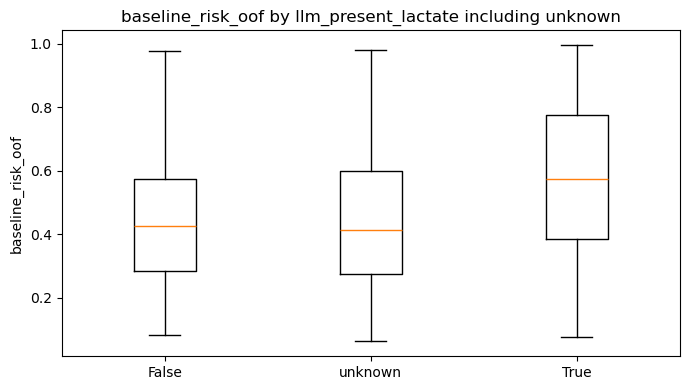

,comparison,n_1,n_2,median_1,median_2,median_difference_g2_minus_g1,U,p_raw,p_holm,significant_holm
0,False vs unknown,230,598,0.426149,0.414577,-0.011572,69652.0,0.774901,0.774901,False
1,unknown vs True,598,790,0.414577,0.573467,0.158890,160447.0,0.000000,0.000000,True
2,False vs True,230,790,0.426149,0.573467,0.147318,62178.0,0.000000,0.000000,True


Kruskal-Wallis across False / unknown / True: H=123.627, p=0.000000

Interpretation helper:
Unknown median risk: 0.4146
Distance to False median: 0.0115
Distance to True median:  0.1589
Unknown is closer to False based on median baseline risk.
************************************************************************


,n,mean_risk,median_risk,std_risk,q25_risk,q75_risk,observed_mortality
group,,,,,,,
False,222,0.4087,0.3705,0.1936,0.2572,0.5218,0.3604
unknown,170,0.4479,0.4083,0.2221,0.2932,0.5936,0.5000
True,1226,0.5380,0.5233,0.2384,0.3482,0.7293,0.5204


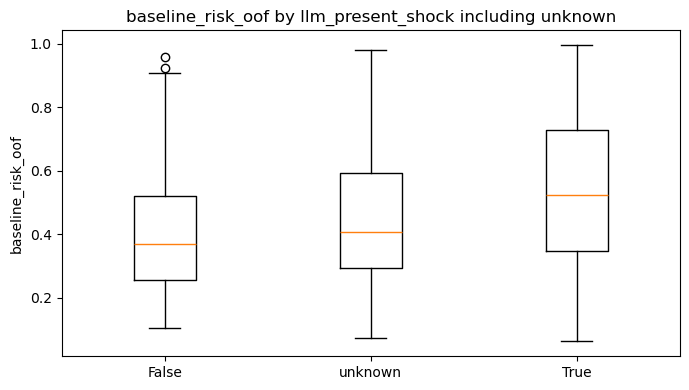

,comparison,n_1,n_2,median_1,median_2,median_difference_g2_minus_g1,U,p_raw,p_holm,significant_holm
0,False vs unknown,222,170,0.370511,0.408319,0.037808,17114.0,0.114326,0.114326,False
1,unknown vs True,170,1226,0.408319,0.523336,0.115017,81406.0,0.000004,0.000007,True
2,False vs True,222,1226,0.370511,0.523336,0.152825,92564.0,0.000000,0.000000,True


Kruskal-Wallis across False / unknown / True: H=70.679, p=0.000000

Interpretation helper:
Unknown median risk: 0.4083
Distance to False median: 0.0378
Distance to True median:  0.1150
Unknown is closer to False based on median baseline risk.
************************************************************************


,n,mean_risk,median_risk,std_risk,q25_risk,q75_risk,observed_mortality
group,,,,,,,
False,756,0.4332,0.3929,0.2149,0.2635,0.5832,0.2646
unknown,247,0.6040,0.5786,0.2256,0.4339,0.8164,0.8381
True,615,0.5687,0.5596,0.2353,0.3764,0.7552,0.6439


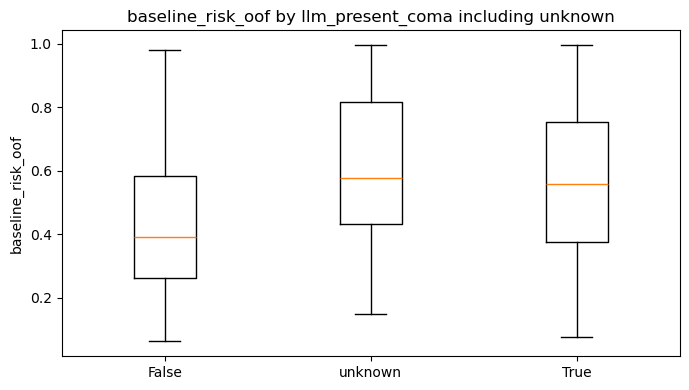

,comparison,n_1,n_2,median_1,median_2,median_difference_g2_minus_g1,U,p_raw,p_holm,significant_holm
0,False vs unknown,756,247,0.392876,0.578644,0.185769,54410.0,0.000000,0.000000,True
1,unknown vs True,247,615,0.578644,0.559613,-0.019032,82263.0,0.056249,0.056249,False
2,False vs True,756,615,0.392876,0.559613,0.166737,155379.0,0.000000,0.000000,True


Kruskal-Wallis across False / unknown / True: H=156.922, p=0.000000

Interpretation helper:
Unknown median risk: 0.5786
Distance to False median: 0.1857
Distance to True median:  0.0190
Unknown is closer to True based on median baseline risk.


In [25]:
unknown_lactate_summary, unknown_lactate_tests = analyze_unknown_category(
    df_model,
    'llm_present_lactate'
)

print('************************************************************************')
unknown_shock_summary, unknown_shock_tests = analyze_unknown_category(
    df_model,
    'llm_present_shock'
)
print('************************************************************************')

unknown_coma_summary, unknown_coma_tests = analyze_unknown_category(
    df_model,
    'llm_present_coma'
)

## Analysis of Unknown in Structured Data

In [26]:
def compare_structured_features_by_llm_group(
    df,
    feature_col,
    structured_cols
):
    tmp = df[[feature_col] + structured_cols].copy()

    tmp[feature_col] = (
        tmp[feature_col]
        .astype('object')
        .where(tmp[feature_col].notna(), 'unknown')
    )

    def clean_label(x):
        if x is True:
            return 'True'
        if x is False:
            return 'False'
        if str(x).lower() == 'true':
            return 'True'
        if str(x).lower() == 'false':
            return 'False'
        return 'unknown'

    tmp['group'] = tmp[feature_col].apply(clean_label)

    summary_parts = []

    for col in structured_cols:
        one = (
            tmp.groupby('group')[col]
            .agg(
                n='count',
                mean='mean',
                median='median',
                std='std',
                q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75),
                missing=lambda x: x.isna().sum()
            )
            .round(4)
        )
        one['variable'] = col
        summary_parts.append(one.reset_index())

    summary = pd.concat(summary_parts, ignore_index=True)
    summary = summary[['variable', 'group', 'n', 'missing', 'mean', 'median', 'std', 'q25', 'q75']]

    display(summary)

    return summary

In [27]:
# Lactate unknown: does it simply mean lactate not documented in text,
# or are structured lactate values also low/missing?
lactate_structured_unknown = compare_structured_features_by_llm_group(
    df_model,
    'llm_present_lactate',
    structured_cols=['Lactate', 'pH', 'Bicarbonate', 'AnionGap']
)

# Shock unknown: compare with hemodynamic structured markers
shock_structured_unknown = compare_structured_features_by_llm_group(
    df_model,
    'llm_present_shock',
    structured_cols=[
        'SBP', 'Lactate', 'pH', 'Bicarbonate',
        'AnionGap', 'received_epinephrine', 'HR'
    ]
)

# Coma unknown: compare with neurological structured marker
coma_structured_unknown = compare_structured_features_by_llm_group(
    df_model,
    'llm_present_coma',
    structured_cols=['GCS_Total', 'SpO2', 'RR', 'pH', 'Lactate']
)

,variable,group,n,missing,mean,median,std,q25,q75
0,Lactate,False,184,46,2.6311,1.7450,2.4724,1.3000,3.0357
1,Lactate,True,705,85,4.4957,3.4000,3.4487,2.0000,5.6875
2,Lactate,unknown,404,194,3.2711,2.3917,2.6146,1.6000,4.0036
3,pH,False,184,46,7.3462,7.3525,0.0920,7.2998,7.4029
4,pH,True,695,95,7.2928,7.3141,0.1288,7.2317,7.3800
5,pH,unknown,453,145,7.3422,7.3562,0.0961,7.3017,7.4000
6,Bicarbonate,False,222,8,22.2542,22.0000,5.1739,19.0000,25.0000
7,Bicarbonate,True,749,41,19.8039,20.0000,5.1707,16.5000,23.0000
8,Bicarbonate,unknown,579,19,22.5492,23.0000,4.4172,20.0000,25.1000
9,AnionGap,False,222,8,15.8096,15.0000,4.2211,13.0000,17.9375


,variable,group,n,missing,mean,median,std,q25,q75
0,SBP,False,222,0,121.7874,120.1042,18.1365,110.0278,132.6171
1,SBP,True,1210,16,111.7670,109.4948,16.8163,101.6307,120.1729
2,SBP,unknown,167,3,121.1480,119.2250,18.4736,108.6736,132.7618
3,Lactate,False,164,58,2.6724,2.0000,2.1684,1.4000,3.1083
4,Lactate,True,1032,194,4.0960,3.0861,3.2783,1.8475,5.2786
5,Lactate,unknown,97,73,3.1940,2.1000,2.8337,1.6500,3.4333
6,pH,False,178,44,7.3628,7.3717,0.0848,7.3208,7.4100
7,pH,True,1046,180,7.3078,7.3300,0.1191,7.2526,7.3846
8,pH,unknown,108,62,7.3300,7.3417,0.1192,7.2900,7.4021
9,Bicarbonate,False,213,9,23.1680,23.3333,4.3997,20.6667,25.0000


,variable,group,n,missing,mean,median,std,q25,q75
0,GCS_Total,False,746,10,10.1767,10.1548,4.1636,6.8616,14.6667
1,GCS_Total,True,600,15,6.5669,4.2679,4.2424,3.0000,9.4429
2,GCS_Total,unknown,230,17,8.3833,7.6458,4.6785,3.3333,13.9583
3,SpO2,False,754,2,96.8793,97.4854,2.9428,95.8279,98.7344
4,SpO2,True,603,12,96.3672,97.8750,4.8902,95.7824,99.1690
5,SpO2,unknown,239,8,95.1725,96.9500,5.9216,94.3964,98.5528
6,RR,False,752,4,20.0584,19.3333,4.1690,17.1206,22.2957
7,RR,True,613,2,21.2249,20.7143,4.6547,17.7500,24.1667
8,RR,unknown,244,3,21.2194,20.5857,4.6039,17.9446,24.1318
9,pH,False,600,156,7.3364,7.3500,0.0917,7.2900,7.3950


In [28]:
print(lactate_df.columns)
print(shock_df.columns)
print(coma_df.columns)

Index(['note_id', 'hadm_id', 'subject_id', 'note_type', 'llm_present',
       'llm_lactate_value', 'llm_evidence_quote', 'n_chunks', 'chunks',
       'structured_lactate_max', 'structured_label', 'chunk_debug_rows'],
      dtype='object')
Index(['note_id', 'hadm_id', 'subject_id', 'note_type', 'llm_present',
       'llm_severity', 'llm_evidence_quotes', 'llm_justification',
       'llm_confidence', 'n_chunks', 'chunks', 'chunk_debug_rows'],
      dtype='object')
Index(['note_id', 'hadm_id', 'subject_id', 'note_type', 'llm_present',
       'llm_evidence_quote', 'n_chunks', 'chunks', 'chunking_mode',
       'chunk_debug_rows'],
      dtype='object')


In [29]:
def build_unknown_review_table(
    df_model,
    llm_df,
    feature_name,
    feature_col_model,
    result_cols=None,
    risk_col='baseline_risk_oof',
    outcome_col='survival_status',
    n=30,
    sort_by='baseline_risk_oof'
):
    """
    Build a table of unknown cases for manual review.
    """

    if result_cols is None:
        result_cols = [
            col for col in [
                'hadm_id',
                'llm_present',
                'llm_severity',
                'llm_evidence_quote',
                'evidence_quote',
                'evidence_quotes',
                'justification',
                'confidence',
                'chunks'
            ]
            if col in llm_df.columns
        ]

    base_cols = ['hadm_id', risk_col, outcome_col, 'risk_strata_3'] + final_vars

    tmp = df_model[base_cols + [feature_col_model]].copy()

    unknown_cases = tmp[tmp[feature_col_model].isna()].copy()

    review = unknown_cases.merge(
        llm_df[result_cols],
        on='hadm_id',
        how='left'
    )

    review = review.sort_values(sort_by, ascending=False).head(n)

    print(f"{feature_name}: selected {len(review)} unknown cases for manual review")
    display(review)

    return review

In [30]:
lactate_unknown_review = build_unknown_review_table(
    df_model=df_model,
    llm_df=lactate_df,
    feature_name='lactate',
    feature_col_model='llm_present_lactate',
    n=30
)

shock_unknown_review = build_unknown_review_table(
    df_model=df_model,
    llm_df=shock_df,
    feature_name='shock',
    feature_col_model='llm_present_shock',
    n=30
)

coma_unknown_review = build_unknown_review_table(
    df_model=df_model,
    llm_df=coma_df,
    feature_name='coma',
    feature_col_model='llm_present_coma',
    n=30
)

lactate: selected 30 unknown cases for manual review


,hadm_id,baseline_risk_oof,survival_status,risk_strata_3,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,...,congestive_heart_failure,BUN,anchor_age,pH,SpO2,GCS_Total,llm_present_lactate,llm_present,llm_evidence_quote,chunks
108,24380025,0.982532,1,high,110.485294,82.538462,15.150000,6.500000,10.666667,0,...,1,55.000000,70,7.030000,74.750000,3.000000,NaN,NaN,NaN,[]
233,22105090,0.976486,1,high,88.548643,95.666667,15.175000,8.240000,11.000000,0,...,0,62.500000,28,7.192500,98.000000,3.000000,NaN,NaN,NaN,['calTCO2-13* Base XS--14 01:15PM BLOOD Lactat...
115,25744732,0.960418,1,high,178.000000,96.000000,NaN,NaN,NaN,1,...,1,NaN,79,7.060000,72.000000,NaN,NaN,NaN,NaN,[]
283,22176511,0.946904,0,high,125.000000,126.333333,8.100000,NaN,6.000000,0,...,0,13.000000,60,6.930000,95.333333,3.000000,NaN,NaN,NaN,[]
12,20186322,0.946537,1,high,119.042484,104.666667,1.475000,7.250000,28.750000,1,...,1,99.000000,74,7.408000,99.166667,4.750000,NaN,NaN,NaN,['calTCO2-36* Base XS-8 03:18AM BLOOD Lactate-...
44,29386188,0.939091,1,high,108.525531,85.281250,3.616667,13.900000,18.750000,0,...,1,39.750000,84,7.200000,75.916667,6.166667,NaN,NaN,NaN,[]
83,20863501,0.936001,0,high,103.012605,124.909091,12.192308,11.162500,18.500000,0,...,0,23.750000,43,7.258462,93.909091,3.375000,NaN,NaN,NaN,[]
87,24459329,0.934456,1,high,82.863191,84.800000,12.550000,10.400000,8.000000,0,...,0,12.000000,55,6.900000,95.900000,3.000000,NaN,NaN,NaN,[]
120,22419363,0.926666,1,high,107.871509,116.253731,10.782353,8.583333,12.500000,0,...,0,11.333333,52,7.034118,91.491803,7.000000,NaN,NaN,NaN,[]
25,23193885,0.912653,1,high,NaN,94.600000,13.250000,NaN,8.000000,0,...,0,80.000000,46,6.870000,NaN,NaN,NaN,NaN,NaN,[]


shock: selected 30 unknown cases for manual review


,hadm_id,baseline_risk_oof,survival_status,risk_strata_3,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,...,congestive_heart_failure,BUN,anchor_age,pH,SpO2,GCS_Total,llm_present_shock,llm_present,llm_severity,chunks
31,24380025,0.982532,1,high,110.485294,82.538462,15.150000,6.500000,10.666667,0,...,1,55.000000,70,7.030000,74.750000,3.000000,NaN,NaN,NaN,[]
1,20050796,0.977129,1,high,95.333333,131.000000,NaN,NaN,NaN,0,...,0,NaN,77,NaN,64.333333,NaN,NaN,NaN,NaN,[]
21,26635682,0.971871,1,high,109.800000,64.333333,15.850000,7.600000,9.500000,0,...,0,17.500000,54,6.860000,83.500000,3.000000,NaN,NaN,NaN,[]
34,25744732,0.960418,1,high,178.000000,96.000000,NaN,NaN,NaN,1,...,1,NaN,79,7.060000,72.000000,NaN,NaN,NaN,NaN,[]
76,22176511,0.946904,0,high,125.000000,126.333333,8.100000,NaN,6.000000,0,...,0,13.000000,60,6.930000,95.333333,3.000000,NaN,NaN,NaN,[]
57,28002167,0.918608,1,high,89.649237,87.086957,11.200000,NaN,NaN,1,...,0,NaN,91,7.460000,NaN,NaN,NaN,NaN,NaN,[]
39,22739148,0.900491,1,high,81.040564,111.529412,5.750000,8.950000,24.500000,1,...,1,67.500000,77,7.312500,74.000000,11.000000,NaN,NaN,NaN,[]
50,28701006,0.879095,1,high,84.571981,81.382353,12.750000,NaN,NaN,0,...,0,NaN,42,7.045000,75.708333,6.000000,NaN,NaN,NaN,[]
120,22323777,0.873225,0,high,119.978992,79.794118,6.516667,8.200000,12.666667,0,...,0,76.666667,91,7.298571,98.117647,6.571429,NaN,NaN,NaN,[]
24,24227159,0.870261,0,high,106.901307,119.222222,5.437500,11.400000,19.666667,0,...,0,34.666667,84,7.223333,92.115385,3.000000,NaN,NaN,NaN,[]


coma: selected 30 unknown cases for manual review


,hadm_id,baseline_risk_oof,survival_status,risk_strata_3,SBP,HR,Lactate,Hemoglobin,Bicarbonate,copd,...,congestive_heart_failure,BUN,anchor_age,pH,SpO2,GCS_Total,llm_present_coma,llm_present,llm_evidence_quote,chunks
46,20638378,0.996284,1,high,97.625000,93.888889,13.733333,7.300000,12.000000,0,...,0,42.000000,91,7.112500,96.833333,3.000000,NaN,NaN,NaN,[]
71,25116813,0.990042,1,high,92.136010,83.632653,13.990000,8.925000,12.500000,0,...,0,84.000000,79,7.084545,78.875000,3.000000,NaN,NaN,NaN,[]
214,28708642,0.989272,1,high,106.323529,108.500000,17.300000,13.500000,10.000000,0,...,0,32.000000,86,7.000000,96.500000,3.000000,NaN,NaN,NaN,[]
135,20412370,0.988946,1,high,100.996732,116.866667,6.223077,10.550000,20.000000,1,...,0,29.250000,47,7.109091,79.388889,3.000000,NaN,NaN,NaN,[]
208,27964902,0.986947,1,high,102.677047,89.583333,16.071429,9.166667,11.000000,0,...,1,23.571429,56,7.143750,95.914286,6.200000,NaN,NaN,NaN,[]
91,26350925,0.982686,1,high,110.646383,69.088235,12.866667,8.800000,9.500000,0,...,1,40.000000,88,7.058000,89.391304,8.000000,NaN,NaN,NaN,[]
64,21619347,0.975506,1,high,154.362745,77.500000,5.800000,11.500000,17.000000,1,...,1,38.000000,80,7.170000,61.500000,4.000000,NaN,NaN,NaN,[]
54,25744732,0.960418,1,high,178.000000,96.000000,NaN,NaN,NaN,1,...,1,NaN,79,7.060000,72.000000,NaN,NaN,NaN,NaN,[]
35,27445915,0.960196,1,high,91.454248,124.500000,13.471429,5.850000,18.000000,0,...,0,20.500000,55,7.031429,97.166667,3.000000,NaN,NaN,NaN,[]
246,22780970,0.956104,1,high,73.250000,82.750000,6.400000,13.000000,12.000000,0,...,0,70.000000,51,6.840000,67.666667,3.000000,NaN,NaN,NaN,[]


## Statistically Test Unknown

In [31]:
import numpy as np
import pandas as pd

from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests


def clean_llm_group_value(x):
    """
    Standardize LLM output into False / unknown / True.
    """
    if pd.isna(x):
        return "unknown"

    if x is True:
        return "True"
    if x is False:
        return "False"

    x_str = str(x).strip().lower()

    if x_str == "true":
        return "True"
    if x_str == "false":
        return "False"
    if x_str in ["none", "null", "nan", "unknown"]:
        return "unknown"

    return "unknown"


def rank_biserial_from_u(u_stat, n1, n2):
    """
    Rank-biserial correlation effect size for Mann-Whitney U.
    Range: -1 to 1.
    Larger absolute values mean stronger group separation.

    Positive value means group 2 tends to have higher values than group 1.
    """
    return (2 * u_stat / (n1 * n2)) - 1


def test_unknown_structured_alignment(
    df,
    feature_col,
    structured_cols,
    group_order=("False", "unknown", "True")
):
    """
    For one LLM feature, test whether related structured variables differ
    across False / unknown / True groups.

    Returns:
    1. descriptive summary
    2. Kruskal-Wallis overall tests
    3. pairwise Mann-Whitney tests with Holm correction
    """

    tmp = df[[feature_col] + structured_cols].copy()
    tmp["llm_group"] = tmp[feature_col].apply(clean_llm_group_value)

    # -----------------------------
    # Descriptive summary
    # -----------------------------
    summary_rows = []

    for var in structured_cols:
        for group in group_order:
            vals = tmp.loc[tmp["llm_group"] == group, var].dropna()

            summary_rows.append({
                "llm_feature": feature_col,
                "structured_variable": var,
                "group": group,
                "n_non_missing": len(vals),
                "n_missing": tmp.loc[tmp["llm_group"] == group, var].isna().sum(),
                "mean": vals.mean() if len(vals) > 0 else np.nan,
                "median": vals.median() if len(vals) > 0 else np.nan,
                "q25": vals.quantile(0.25) if len(vals) > 0 else np.nan,
                "q75": vals.quantile(0.75) if len(vals) > 0 else np.nan,
                "std": vals.std() if len(vals) > 1 else np.nan
            })

    summary_df = pd.DataFrame(summary_rows).round(4)

    # -----------------------------
    # Kruskal-Wallis overall tests
    # -----------------------------
    kruskal_rows = []

    for var in structured_cols:
        groups = []
        group_sizes = {}

        for group in group_order:
            vals = tmp.loc[tmp["llm_group"] == group, var].dropna()
            group_sizes[group] = len(vals)

            if len(vals) > 0:
                groups.append(vals.values)

        if len(groups) >= 2:
            h_stat, p_value = kruskal(*groups)
        else:
            h_stat, p_value = np.nan, np.nan

        kruskal_rows.append({
            "llm_feature": feature_col,
            "structured_variable": var,
            "test": "Kruskal-Wallis",
            "H": h_stat,
            "p_raw": p_value,
            "n_false": group_sizes.get("False", 0),
            "n_unknown": group_sizes.get("unknown", 0),
            "n_true": group_sizes.get("True", 0)
        })

    kruskal_df = pd.DataFrame(kruskal_rows)

    # Holm correction across structured variables for this LLM feature
    valid_mask = kruskal_df["p_raw"].notna()

    if valid_mask.sum() > 0:
        _, p_adj, _, _ = multipletests(
            kruskal_df.loc[valid_mask, "p_raw"],
            method="holm"
        )
        kruskal_df.loc[valid_mask, "p_holm"] = p_adj
    else:
        kruskal_df["p_holm"] = np.nan

    kruskal_df["significant_holm"] = kruskal_df["p_holm"] < 0.05
    kruskal_df = kruskal_df.round(6)

    # -----------------------------
    # Pairwise Mann-Whitney tests
    # -----------------------------
    pairwise_comparisons = [
        ("False", "unknown"),
        ("unknown", "True"),
        ("False", "True")
    ]

    pairwise_rows = []

    for var in structured_cols:
        for g1, g2 in pairwise_comparisons:
            vals1 = tmp.loc[tmp["llm_group"] == g1, var].dropna()
            vals2 = tmp.loc[tmp["llm_group"] == g2, var].dropna()

            if len(vals1) > 0 and len(vals2) > 0:
                u_stat, p_value = mannwhitneyu(
                    vals1,
                    vals2,
                    alternative="two-sided"
                )

                effect_size = rank_biserial_from_u(
                    u_stat,
                    len(vals1),
                    len(vals2)
                )

                pairwise_rows.append({
                    "llm_feature": feature_col,
                    "structured_variable": var,
                    "comparison": f"{g1} vs {g2}",
                    "group_1": g1,
                    "group_2": g2,
                    "n_1": len(vals1),
                    "n_2": len(vals2),
                    "median_1": vals1.median(),
                    "median_2": vals2.median(),
                    "median_difference_group2_minus_group1": vals2.median() - vals1.median(),
                    "U": u_stat,
                    "p_raw": p_value,
                    "rank_biserial_effect_size": effect_size
                })

    pairwise_df = pd.DataFrame(pairwise_rows)

    # Holm correction across all pairwise tests for this LLM feature
    if len(pairwise_df) > 0:
        _, p_adj, _, _ = multipletests(
            pairwise_df["p_raw"],
            method="holm"
        )
        pairwise_df["p_holm"] = p_adj
        pairwise_df["significant_holm"] = pairwise_df["p_holm"] < 0.05

    pairwise_df = pairwise_df.round(6)

    return summary_df, kruskal_df, pairwise_df

In [32]:
# -----------------------------
# Lactate unknown analysis
# -----------------------------
lactate_summary_stats, lactate_kruskal_tests, lactate_pairwise_tests = test_unknown_structured_alignment(
    df=df_model,
    feature_col="llm_present_lactate",
    structured_cols=["Lactate", "pH", "Bicarbonate", "AnionGap"]
)

#display(lactate_summary_stats)
#display(lactate_kruskal_tests)
#display(lactate_pairwise_tests)

print('************************************************************************************')
# -----------------------------
# Shock unknown analysis
# -----------------------------
shock_summary_stats, shock_kruskal_tests, shock_pairwise_tests = test_unknown_structured_alignment(
    df=df_model,
    feature_col="llm_present_shock",
    structured_cols=[
        "SBP",
        "Lactate",
        "pH",
        "Bicarbonate",
        "AnionGap",
        "received_epinephrine",
        "HR"
    ]
)

#display(shock_summary_stats)
#display(shock_kruskal_tests)
#display(shock_pairwise_tests)

print('************************************************************************************')
# -----------------------------
# Coma unknown analysis
# -----------------------------
coma_summary_stats, coma_kruskal_tests, coma_pairwise_tests = test_unknown_structured_alignment(
    df=df_model,
    feature_col="llm_present_coma",
    structured_cols=[
        "GCS_Total",
        "SpO2",
        "RR",
        "pH",
        "Lactate"
    ]
)

#display(coma_summary_stats)
#display(coma_kruskal_tests)
#display(coma_pairwise_tests)

************************************************************************************
************************************************************************************


In [33]:
all_kruskal_tests = pd.concat(
    [
        lactate_kruskal_tests,
        shock_kruskal_tests,
        coma_kruskal_tests
    ],
    ignore_index=True
)

all_pairwise_tests = pd.concat(
    [
        lactate_pairwise_tests,
        shock_pairwise_tests,
        coma_pairwise_tests
    ],
    ignore_index=True
)

#display(all_kruskal_tests)
#display(all_pairwise_tests)

#all_kruskal_tests.to_csv("../Outputs/all_unknown_kruskal_tests.csv", index=False)
#all_pairwise_tests.to_csv("../Outputs/all_unknown_pairwise_tests.csv", index=False)

In [34]:
unknown_pairwise_only = all_pairwise_tests[
    all_pairwise_tests["comparison"].isin([
        "False vs unknown",
        "unknown vs True"
    ])
].copy()

display(unknown_pairwise_only)

unknown_pairwise_only.to_csv('unknown_pairwise_only.csv')

,llm_feature,structured_variable,comparison,group_1,group_2,n_1,n_2,median_1,median_2,median_difference_group2_minus_group1,U,p_raw,rank_biserial_effect_size,p_holm,significant_holm
0,llm_present_lactate,Lactate,False vs unknown,False,unknown,184,404,1.745000,2.391667,0.646667,28909.0,0.000015,-0.222207,0.000061,True
1,llm_present_lactate,Lactate,unknown vs True,unknown,True,404,705,2.391667,3.400000,1.008333,106990.0,0.000000,-0.248718,0.000000,True
3,llm_present_lactate,pH,False vs unknown,False,unknown,184,453,7.352500,7.356250,0.003750,41968.5,0.889676,0.007018,0.889676,False
4,llm_present_lactate,pH,unknown vs True,unknown,True,453,695,7.356250,7.314054,-0.042196,194527.0,0.000000,0.235739,0.000000,True
6,llm_present_lactate,Bicarbonate,False vs unknown,False,unknown,222,579,22.000000,23.000000,1.000000,58315.0,0.042150,-0.092642,0.126450,False
7,llm_present_lactate,Bicarbonate,unknown vs True,unknown,True,579,749,23.000000,20.000000,-3.000000,291585.0,0.000000,0.344729,0.000000,True
9,llm_present_lactate,AnionGap,False vs unknown,False,unknown,222,578,15.000000,14.500000,-0.500000,68981.5,0.099172,0.075182,0.198343,False
10,llm_present_lactate,AnionGap,unknown vs True,unknown,True,578,750,14.500000,17.250000,2.750000,136604.5,0.000000,-0.369760,0.000000,True
12,llm_present_shock,SBP,False vs unknown,False,unknown,222,167,120.104167,119.225000,-0.879167,18997.0,0.675501,0.024815,1.000000,False
13,llm_present_shock,SBP,unknown vs True,unknown,True,167,1210,119.225000,109.494756,-9.730244,133031.0,0.000000,0.316682,0.000000,True


In [35]:
unknown_pairwise_only.columns

Index(['llm_feature', 'structured_variable', 'comparison', 'group_1',
       'group_2', 'n_1', 'n_2', 'median_1', 'median_2',
       'median_difference_group2_minus_group1', 'U', 'p_raw',
       'rank_biserial_effect_size', 'p_holm', 'significant_holm'],
      dtype='object')